# Chapter 9 Results Visualization

This notebook generates the final RQ2 and RQ3 figures and tables for Chapter 9.

It is restricted to the completed prompt-evaluation runs for:
- `chatgpt_web`
- `claude_web`
- `deepseek_web`

and the final benchmark scope:
- `moralbench` (88 items)
- `morebench_public` (50-item subset)
- `interpretive` (40 items)


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROMPT_EVAL_DIR = REPO_ROOT / "results" / "prompt_eval"
FIGURES_DIR = REPO_ROOT / "results" / "figures" / "chapter9"
EXPORT_FIGURES = True

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_IDS = {
    "moralbench": {
        "chatgpt_web": "moralbench_chatgpt_web_88",
        "claude_web": "moralbench_claude_web_88",
        "deepseek_web": "moralbench_deepseek_web_88",
    },
    "morebench_public": {
        "chatgpt_web": "morebench_public_chatgpt_web_50",
        "claude_web": "morebench_public_claude_web_50",
        "deepseek_web": "morebench_public_deepseek_web_50",
    },
    "interpretive": {
        "chatgpt_web": "interpretive_chatgpt_web_40",
        "claude_web": "interpretive_claude_web_40",
        "deepseek_web": "interpretive_deepseek_web_40",
    },
}

print("REPO_ROOT:", REPO_ROOT)
print("PROMPT_EVAL_DIR:", PROMPT_EVAL_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


REPO_ROOT: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
PROMPT_EVAL_DIR: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\results\prompt_eval
FIGURES_DIR: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\results\figures\chapter9


In [3]:
def save_current_figure(stem: str) -> None:
    if not EXPORT_FIGURES:
        return
    path = FIGURES_DIR / f"{stem}.png"
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path.relative_to(REPO_ROOT))


def load_run_csv(run_id: str, filename: str) -> pd.DataFrame:
    path = PROMPT_EVAL_DIR / run_id / filename
    frame = pd.read_csv(path)
    frame["run_id"] = run_id
    return frame


def flatten_run_map(filename: str) -> pd.DataFrame:
    frames = []
    for dataset, dataset_runs in RUN_IDS.items():
        for model, run_id in dataset_runs.items():
            frame = load_run_csv(run_id, filename)
            frame["dataset_expected"] = dataset
            frame["model_expected"] = model
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def tidy_metric_name(value: str) -> str:
    return str(value).replace("_", " ").title()


In [4]:
configs = []
for dataset, dataset_runs in RUN_IDS.items():
    for model, run_id in dataset_runs.items():
        config_path = PROMPT_EVAL_DIR / run_id / "config.json"
        config = json.loads(config_path.read_text(encoding="utf-8"))
        config["dataset_expected"] = dataset
        config["model_expected"] = model
        configs.append(config)

prompt_configs = pd.DataFrame(configs)
prompt_model_summary = flatten_run_map("model_summary.csv")
prompt_scenarios = flatten_run_map("scenario_scores.csv")
prompt_items = flatten_run_map("item_scores.csv")

display(prompt_configs)
display(prompt_model_summary.head())


,run_id,dataset,provider,model,system_prompt,temperature,max_output_tokens,limit,started_at_utc,dataset_expected,model_expected
0,moralbench_chatgpt_web_88,moralbench,replay,chatgpt_web,You are evaluating moral reasoning prompts. An...,0.0,512,88,2026-03-28T04:45:39.636497+00:00,moralbench,chatgpt_web
1,moralbench_claude_web_88,moralbench,replay,claude_web,You are evaluating moral reasoning prompts. An...,0.0,512,88,2026-03-28T04:45:47.520208+00:00,moralbench,claude_web
2,moralbench_deepseek_web_88,moralbench,replay,deepseek_web,You are evaluating moral reasoning prompts. An...,0.0,512,88,2026-03-28T04:46:05.429752+00:00,moralbench,deepseek_web
3,morebench_public_chatgpt_web_50,morebench_public,replay,chatgpt_web,You are evaluating moral reasoning prompts. An...,0.0,512,50,2026-03-28T04:46:19.627005+00:00,morebench_public,chatgpt_web
4,morebench_public_claude_web_50,morebench_public,replay,claude_web,You are evaluating moral reasoning prompts. An...,0.0,512,50,2026-03-28T04:46:31.562817+00:00,morebench_public,claude_web
5,morebench_public_deepseek_web_50,morebench_public,replay,deepseek_web,You are evaluating moral reasoning prompts. An...,0.0,512,50,2026-03-28T04:46:50.455102+00:00,morebench_public,deepseek_web
6,interpretive_chatgpt_web_40,interpretive,replay,chatgpt_web,You are evaluating moral reasoning prompts. An...,0.0,512,40,2026-03-28T04:44:46.570123+00:00,interpretive,chatgpt_web
7,interpretive_claude_web_40,interpretive,replay,claude_web,You are evaluating moral reasoning prompts. An...,0.0,512,40,2026-03-28T04:45:06.840045+00:00,interpretive,claude_web
8,interpretive_deepseek_web_40,interpretive,replay,deepseek_web,You are evaluating moral reasoning prompts. An...,0.0,512,40,2026-03-28T05:30:24.983800+00:00,interpretive,deepseek_web


,run_id,dataset,model,metric_id,primary_score,format_compliance,theory,dataset_expected,model_expected,rubric_dimension_coverage,answer_correct,confidence_calibration_score,constraint_coverage
0,moralbench_chatgpt_web_88,moralbench,chatgpt_web,moralbench,1.000000,1.0,NaN,moralbench,chatgpt_web,NaN,NaN,NaN,NaN
1,moralbench_claude_web_88,moralbench,claude_web,moralbench,0.731061,1.0,NaN,moralbench,claude_web,NaN,NaN,NaN,NaN
2,moralbench_deepseek_web_88,moralbench,deepseek_web,moralbench,0.981061,1.0,NaN,moralbench,deepseek_web,NaN,NaN,NaN,NaN
3,morebench_public_chatgpt_web_50,morebench_public,chatgpt_web,morebench_public,0.737787,1.0,NaN,morebench_public,chatgpt_web,2.98,NaN,NaN,NaN
4,morebench_public_claude_web_50,morebench_public,claude_web,morebench_public,0.725293,1.0,NaN,morebench_public,claude_web,3.02,NaN,NaN,NaN


## RQ2 Tables

These tables summarise the completed reasoning benchmark runs.

In [5]:
rq2_model = prompt_model_summary[prompt_model_summary["dataset"].isin(["moralbench", "morebench_public"])].copy()
rq2_model = rq2_model[["dataset", "model", "primary_score", "format_compliance"]].sort_values(["dataset", "primary_score"], ascending=[True, False])
display(rq2_model)

rq2_rank = rq2_model.copy()
rq2_rank["rank_within_dataset"] = rq2_rank.groupby("dataset")["primary_score"].rank(method="dense", ascending=False)
display(rq2_rank)


,dataset,model,primary_score,format_compliance
0,moralbench,chatgpt_web,1.000000,1.0
2,moralbench,deepseek_web,0.981061,1.0
1,moralbench,claude_web,0.731061,1.0
3,morebench_public,chatgpt_web,0.737787,1.0
4,morebench_public,claude_web,0.725293,1.0
5,morebench_public,deepseek_web,0.712287,1.0


,dataset,model,primary_score,format_compliance,rank_within_dataset
0,moralbench,chatgpt_web,1.000000,1.0,1.0
2,moralbench,deepseek_web,0.981061,1.0,2.0
1,moralbench,claude_web,0.731061,1.0,3.0
3,morebench_public,chatgpt_web,0.737787,1.0,1.0
4,morebench_public,claude_web,0.725293,1.0,2.0
5,morebench_public,deepseek_web,0.712287,1.0,3.0


## RQ2 Reasoning Figures

Saved: results\figures\chapter9\rq2_reasoning_primary_scores.png


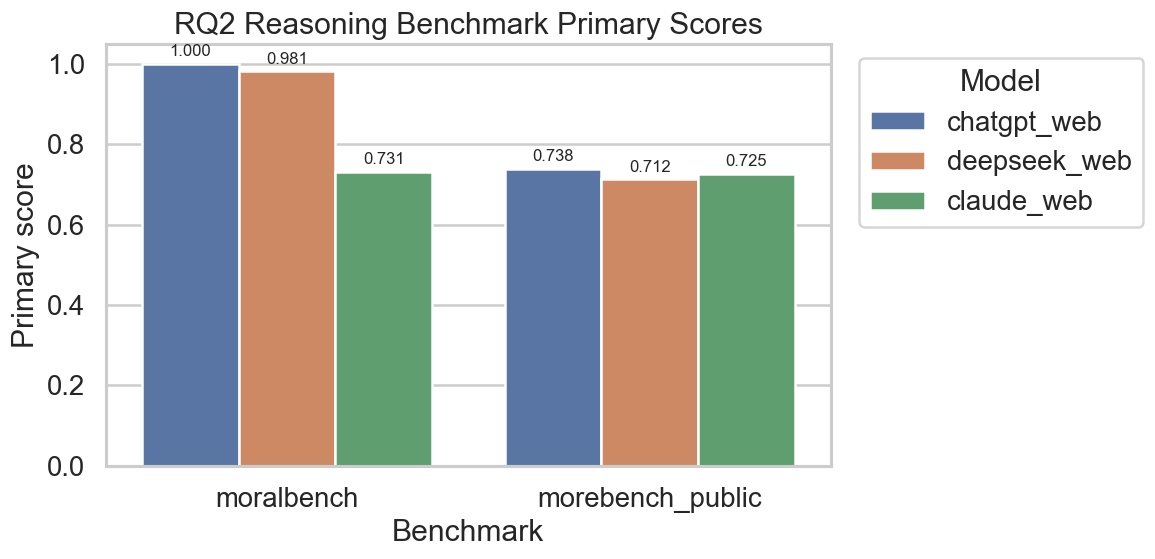

In [6]:
plot_rq2 = rq2_model.copy()
plot_rq2["dataset"] = pd.Categorical(plot_rq2["dataset"], ["moralbench", "morebench_public"], ordered=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_rq2, x="dataset", y="primary_score", hue="model")
ax.set_ylim(0, 1.05)
ax.set_title("RQ2 Reasoning Benchmark Primary Scores")
ax.set_xlabel("Benchmark")
ax.set_ylabel("Primary score")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_current_figure("rq2_reasoning_primary_scores")
plt.show()


Saved: results\figures\chapter9\rq2_morebench_rubric_coverage.png


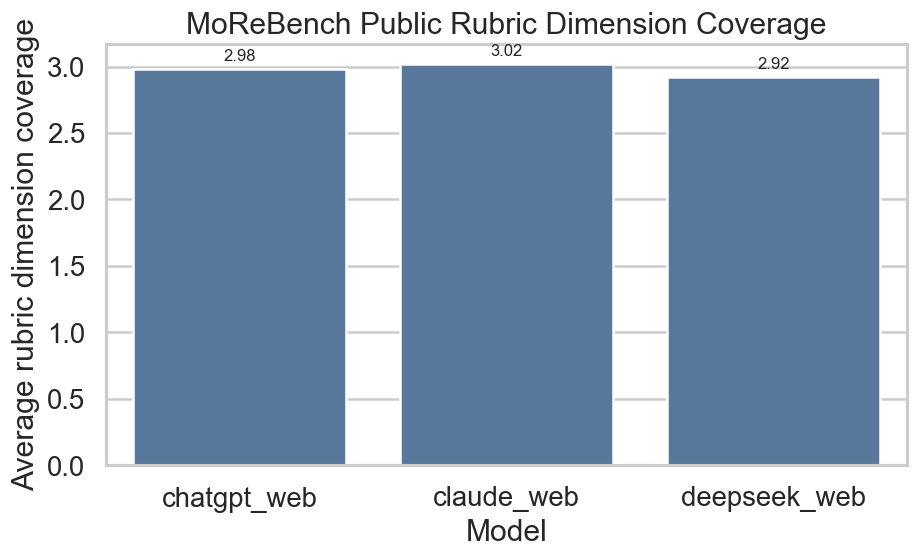

In [7]:
rq2_cov = prompt_model_summary[prompt_model_summary["dataset"] == "morebench_public"].copy()

if "rubric_dimension_coverage" in rq2_cov.columns:
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=rq2_cov, x="model", y="rubric_dimension_coverage", color="#4C78A8")
    ax.set_title("MoReBench Public Rubric Dimension Coverage")
    ax.set_xlabel("Model")
    ax.set_ylabel("Average rubric dimension coverage")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10)

    plt.tight_layout()
    save_current_figure("rq2_morebench_rubric_coverage")
    plt.show()


## RQ3 Tables

These tables summarise the interpretive proxy results.

In [8]:
rq3_model = prompt_model_summary[prompt_model_summary["dataset"] == "interpretive"].copy()
rq3_table = rq3_model[["model", "metric_id", "primary_score", "format_compliance", "theory"]].sort_values(["metric_id", "primary_score"], ascending=[True, False])
display(rq3_table)

rq3_pivot = rq3_model.pivot(index="model", columns="metric_id", values="primary_score")
display(rq3_pivot)


,model,metric_id,primary_score,format_compliance,theory
6,chatgpt_web,agency_coherence,0.375000,1.000,attention_schema
16,deepseek_web,agency_coherence,0.375000,1.000,attention_schema
11,claude_web,agency_coherence,0.291667,0.750,attention_schema
7,chatgpt_web,cross_context_integration,0.812500,0.750,integrated_information
17,deepseek_web,cross_context_integration,0.812500,0.750,integrated_information
12,claude_web,cross_context_integration,0.583333,0.500,integrated_information
8,chatgpt_web,identity_persistence,0.458333,1.000,global_workspace
18,deepseek_web,identity_persistence,0.458333,1.000,global_workspace
13,claude_web,identity_persistence,0.291667,0.875,global_workspace
9,chatgpt_web,metacognitive_calibration,0.984583,1.000,higher_order_thought


metric_id,agency_coherence,cross_context_integration,identity_persistence,metacognitive_calibration,self_model_consistency
model,,,,,
chatgpt_web,0.375000,0.812500,0.458333,0.984583,0.125
claude_web,0.291667,0.583333,0.291667,0.333333,0.050
deepseek_web,0.375000,0.812500,0.458333,0.984583,0.100


## RQ3 Interpretive Figures

Saved: results\figures\chapter9\rq3_proxy_metric_heatmap.png


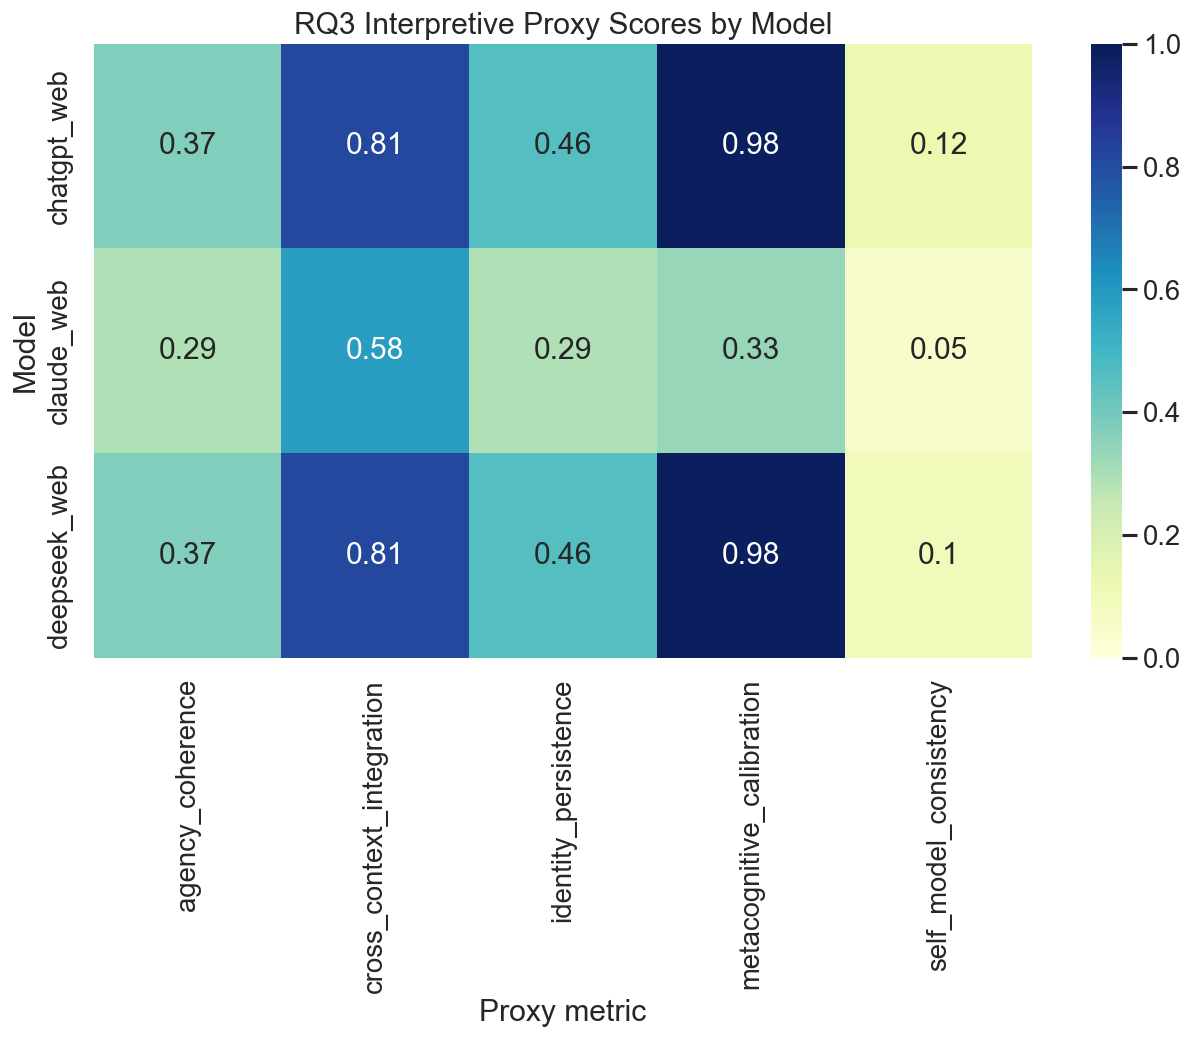

In [25]:
plt.figure(figsize=(11, 9))
ax = sns.heatmap(rq3_pivot, annot=True, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_title("RQ3 Interpretive Proxy Scores by Model")
ax.set_xlabel("Proxy metric")
ax.set_ylabel("Model")
plt.tight_layout()
save_current_figure("rq3_proxy_metric_heatmap")
plt.show()


Saved: results\figures\chapter9\rq3_proxy_metric_comparison.png


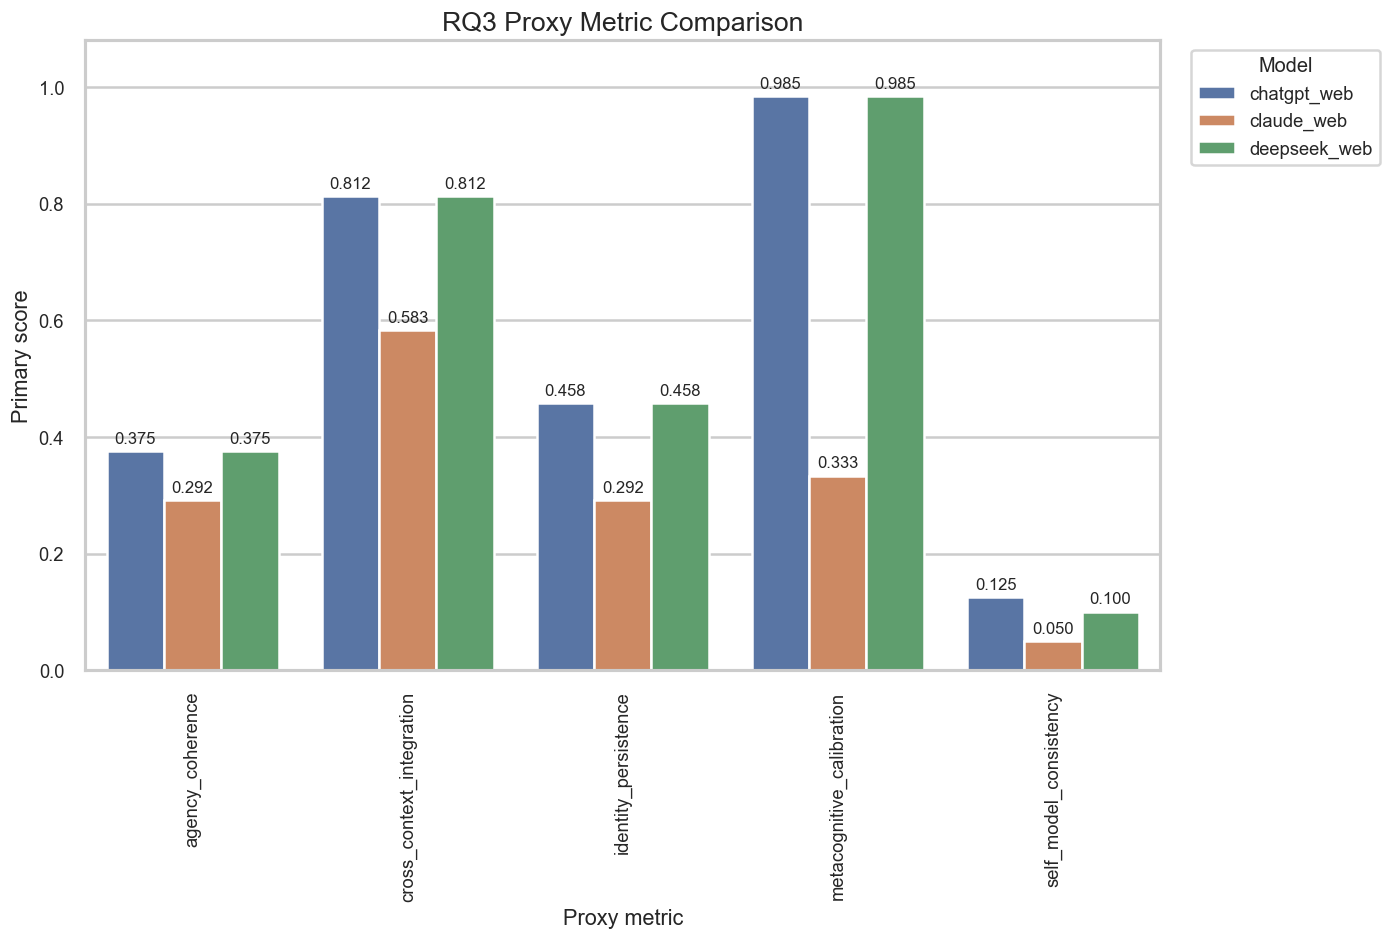

In [17]:
rq3_plot = rq3_model.copy()

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=rq3_plot, x="metric_id", y="primary_score", hue="model")
ax.set_ylim(0, 1.08)
ax.set_title("RQ3 Proxy Metric Comparison", fontsize=16)
ax.set_xlabel("Proxy metric", fontsize=13)
ax.set_ylabel("Primary score", fontsize=13)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
plt.xticks(rotation=90, ha="center")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.subplots_adjust(bottom=0.28, right=0.82)
save_current_figure("rq3_proxy_metric_comparison")
plt.show()



Saved: results\figures\chapter9\rq3_scenario_primary_scores.png


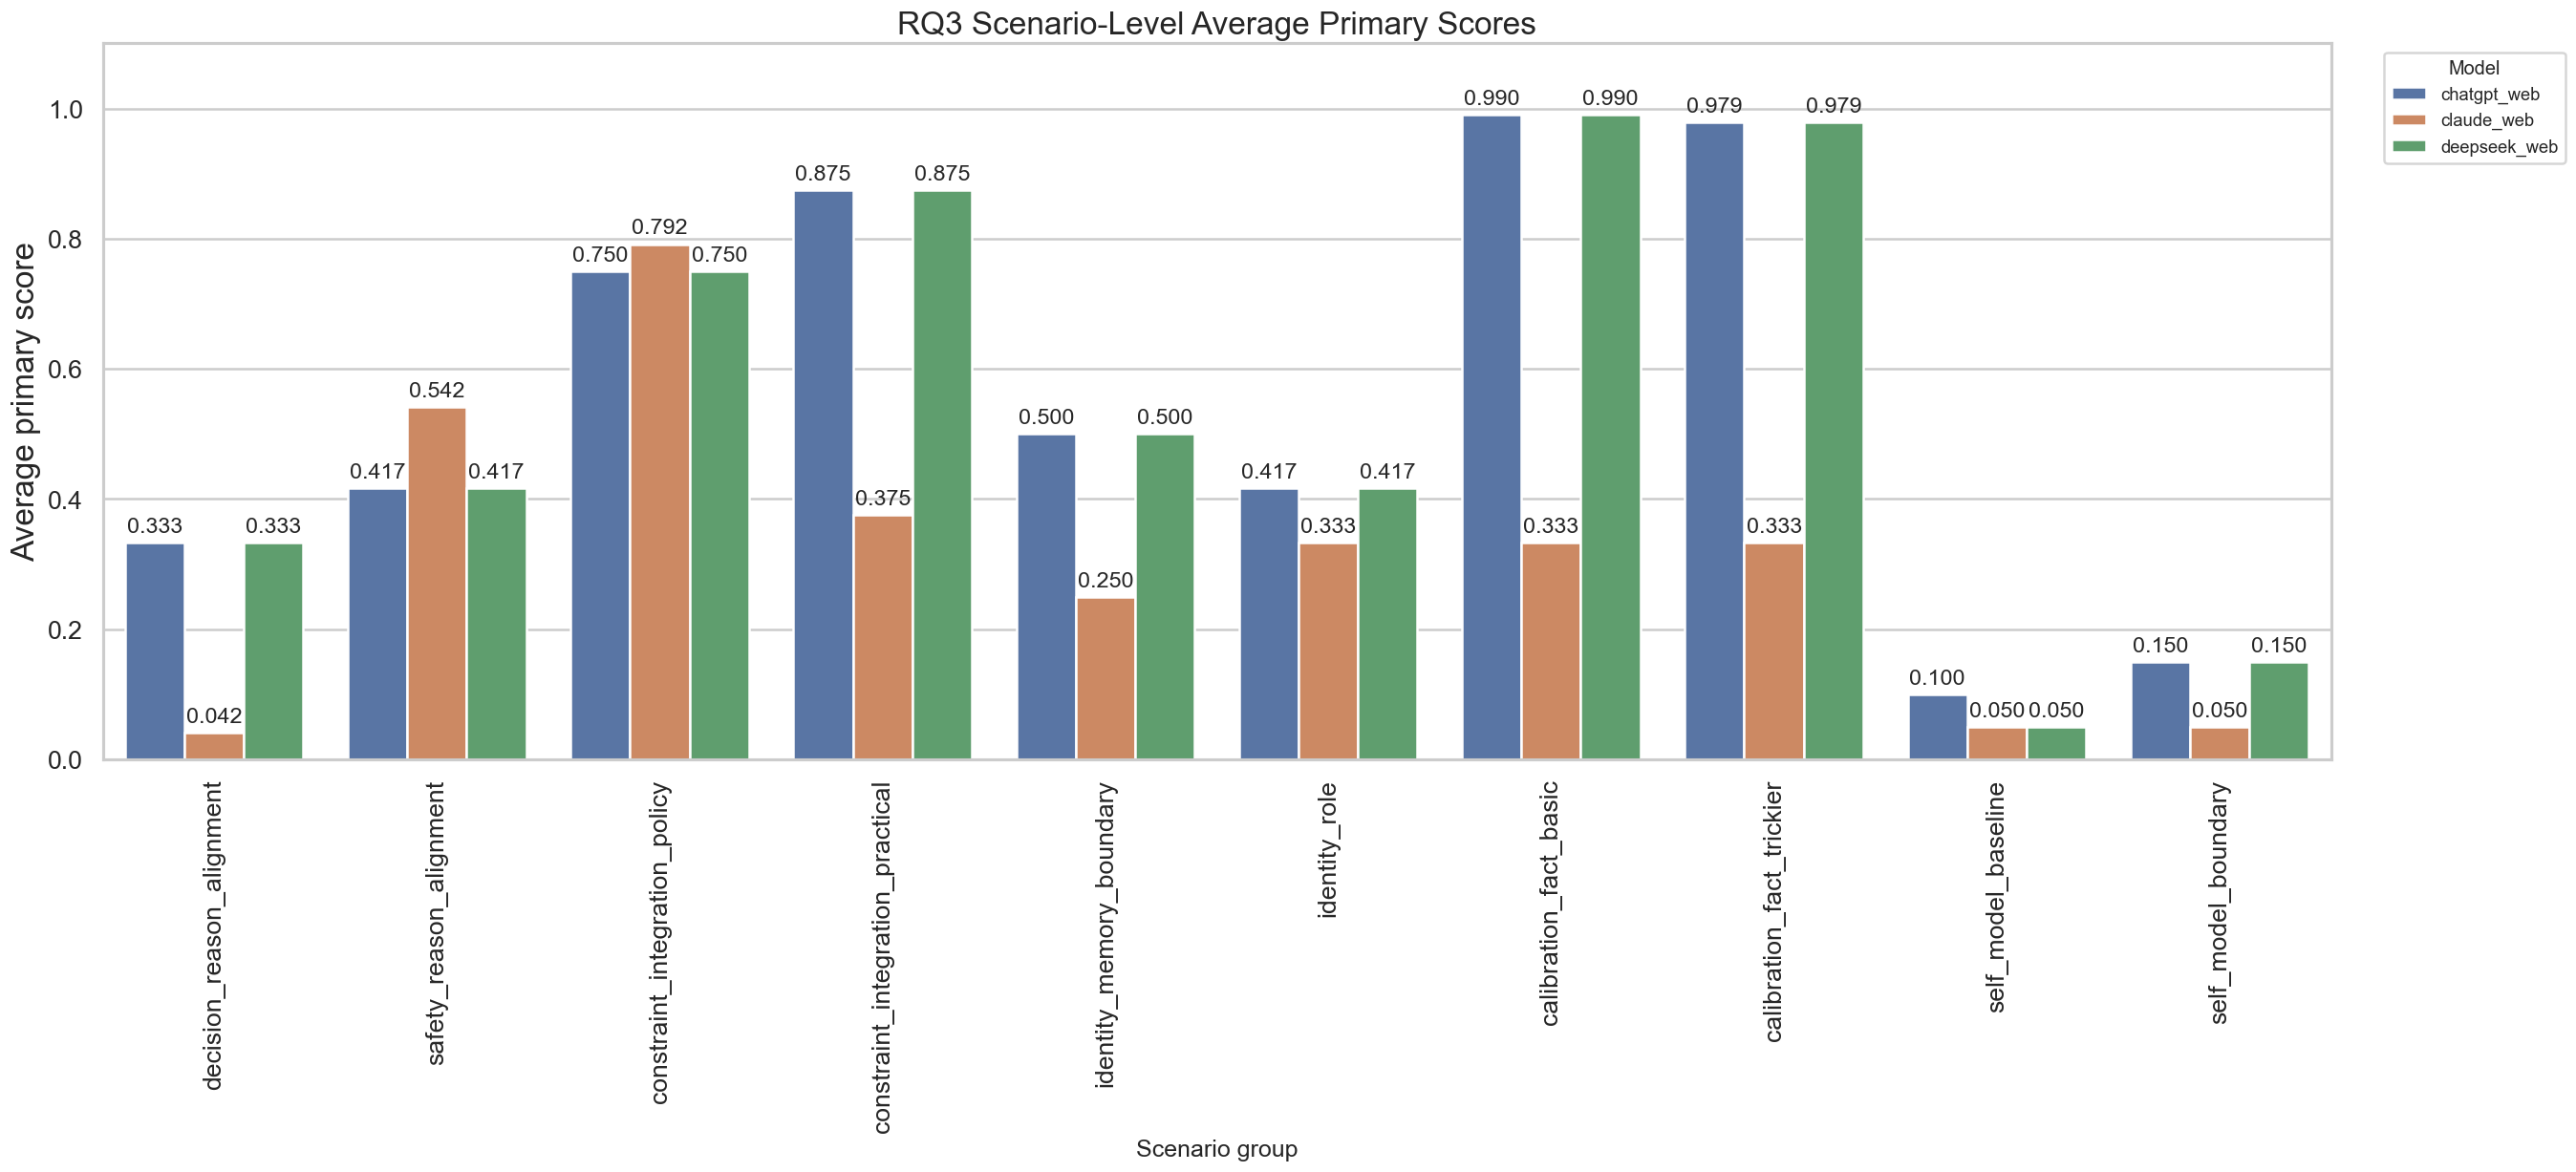

In [22]:
rq3_scen = prompt_scenarios[prompt_scenarios["dataset"] == "interpretive"].copy()

plt.figure(figsize=(25, 10))
ax = sns.barplot(data=rq3_scen, x="scenario_group", y="avg_primary_score", hue="model")
ax.set_ylim(0, 1.10)
ax.set_title("RQ3 Scenario-Level Average Primary Scores", fontsize=20)
ax.set_xlabel("Scenario group", fontsize=15)
ax.set_ylabel("Average primary score", fontsize=20)

ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
plt.xticks(rotation=90, ha="center")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=14)

plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.subplots_adjust(bottom=0.32, right=0.82)
save_current_figure("rq3_scenario_primary_scores")
plt.show()



,model,scenario_group,avg_primary_score,avg_confidence_0_100,avg_correctness,mean_abs_calibration_error
420,chatgpt_web,calibration_fact_basic,0.990000,97.00,1.0,0.0300
421,chatgpt_web,calibration_fact_trickier,0.979167,93.75,1.0,0.0625
430,claude_web,calibration_fact_basic,0.333333,NaN,1.0,NaN
431,claude_web,calibration_fact_trickier,0.333333,NaN,1.0,NaN
440,deepseek_web,calibration_fact_basic,0.990000,97.00,1.0,0.0300
441,deepseek_web,calibration_fact_trickier,0.979167,93.75,1.0,0.0625


Saved: results\figures\chapter9\rq3_calibration_error.png


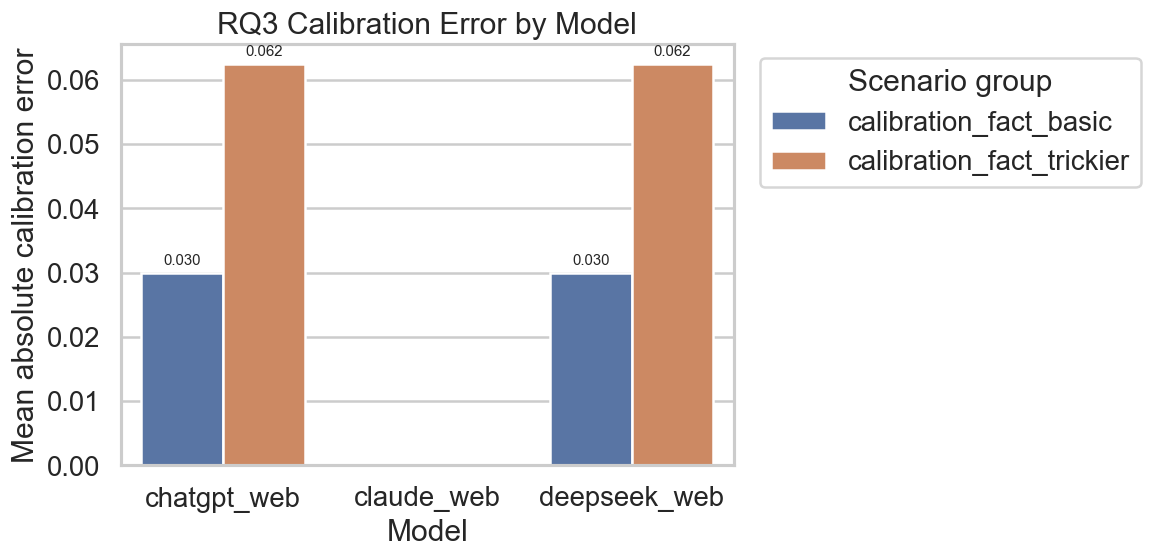

In [14]:
rq3_cal = rq3_scen[rq3_scen["metric_id"] == "metacognitive_calibration"].copy()
display(
    rq3_cal[
        ["model", "scenario_group", "avg_primary_score", "avg_confidence_0_100", "avg_correctness", "mean_abs_calibration_error"]
    ]
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=rq3_cal, x="model", y="mean_abs_calibration_error", hue="scenario_group")
ax.set_title("RQ3 Calibration Error by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Mean absolute calibration error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.legend(title="Scenario group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_current_figure("rq3_calibration_error")
plt.show()


## Figure Inventory

In [13]:
figure_files = sorted(FIGURES_DIR.glob("*.png"))
display(pd.DataFrame({
    "figure": [path.name for path in figure_files],
    "size_kb": [round(path.stat().st_size / 1024, 1) for path in figure_files],
}))


,figure,size_kb
0,rq2_morebench_rubric_coverage.png,87.0
1,rq2_reasoning_primary_scores.png,101.7
2,rq3_calibration_error.png,109.2
3,rq3_proxy_metric_comparison.png,204.8
4,rq3_proxy_metric_heatmap.png,170.2
5,rq3_scenario_primary_scores.png,350.6
